In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import contacts,distances
import io
from PIL import Image
from collections import defaultdict
import itertools
import pickle
import seaborn as sns
import glob
import matplotlib.ticker as ticker

In [2]:
# =========================
# USER INPUT
# =========================
pdb_file = "/Users/achakrab/Documents/asn/trj/fas/last_frame.pdb"
xtc_file = "/Users/achakrab/Documents/asn/trj/fas/pro_lig.xtc"
#ligand_resname = "*"       # change if needed
contact_cutoff = 3.0          # Å
frame_skip = 10              # ← skip every 100th frame

In [7]:
# =========================
# LOAD SYSTEM
# =========================
u = mda.Universe(pdb_file, xtc_file)

protein = u.select_atoms("protein")
#ligand = u.select_atoms(f"resname {ligand_resname}")

ligand = u.select_atoms("not protein")


residues = protein.residues
n_res = len(residues)

In [13]:
print("Protein atoms:", len(protein))
print("Ligand atoms:", len(ligand))
print("Ligand residues:", len(ligand.residues))


Protein atoms: 294
Ligand atoms: 38
Ligand residues: 1


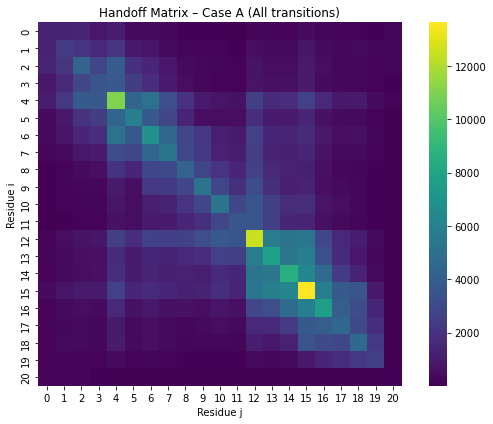

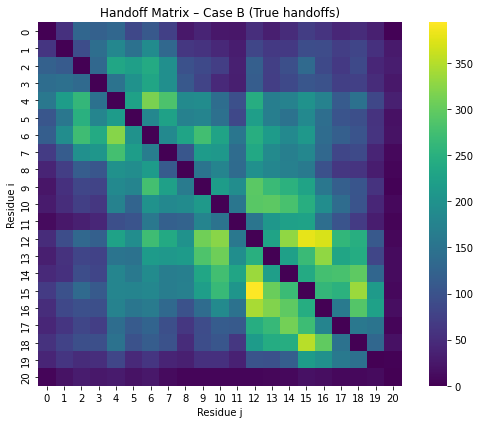

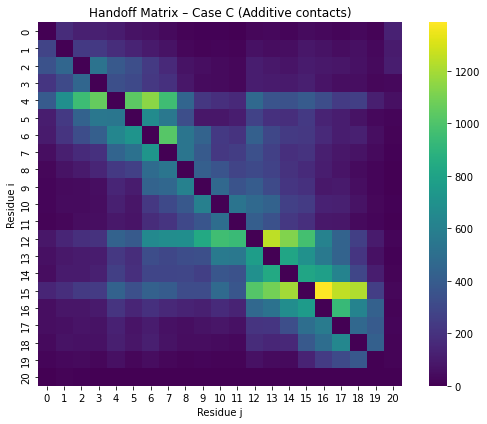

In [12]:
# =========================
# CONTACT DETECTION
# =========================
def contact_residues(residues, ligand, cutoff):
    """Return set of residue indices in contact with ligand"""
    contacts = set()
    for i, res in enumerate(residues):
        if np.any(mda.lib.distances.distance_array(
                res.atoms.positions,
                ligand.positions
            ) < cutoff):
            contacts.add(i)
    return contacts

# =========================
# BUILD CONTACT TIME SERIES
# =========================
contact_series = []

for ts in u.trajectory[::frame_skip]:  # ← skipping frames
    contact_series.append(contact_residues(residues, ligand, contact_cutoff))

# =========================
# INITIALIZE HANDOFF MATRICES
# =========================
H_A = np.zeros((n_res, n_res), dtype=int)
H_B = np.zeros((n_res, n_res), dtype=int)
H_C = np.zeros((n_res, n_res), dtype=int)

# =========================
# POPULATE MATRICES
# =========================
for t in range(len(contact_series) - 1):
    Ct = contact_series[t]
    Ct1 = contact_series[t + 1]

    # CASE A: all transitions
    for i in Ct:
        for j in Ct1:
            H_A[i, j] += 1

    # CASE B: true handoff (i lost, j gained)
    for i in Ct - Ct1:
        for j in Ct1 - Ct:
            H_B[i, j] += 1

    # CASE C: additive (i retained, j gained)
    for i in Ct & Ct1:
        for j in Ct1 - Ct:
            H_C[i, j] += 1

# =========================
# PLOTTING FUNCTION
# =========================
def plot_handoff_matrix(matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, cmap="viridis", square=True)
    plt.title(title)
    plt.xlabel("Residue j")
    plt.ylabel("Residue i")
    plt.tight_layout()
    plt.show()

# =========================
# VISUALIZE RESULTS
# =========================
plot_handoff_matrix(H_A, "Handoff Matrix – Case A (All transitions)")
plot_handoff_matrix(H_B, "Handoff Matrix – Case B (True handoffs)")
plot_handoff_matrix(H_C, "Handoff Matrix – Case C (Additive contacts)")

In [14]:
from collections import defaultdict
from itertools import tee

def pairwise(iterable):
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)

# Assume: contact_series is a list of sets (e.g., quintuplets or any contact sets)
dictionary_transitions_sorted = defaultdict(int)

for c1, c2 in pairwise(contact_series):
    if c1 != c2:
        dictionary_transitions_sorted[(tuple(sorted(c1)), tuple(sorted(c2)))] += 1

# Sort transitions by frequency
dictionary_transitions_sorted = dict(sorted(dictionary_transitions_sorted.items(), key=lambda x: x[1], reverse=True))


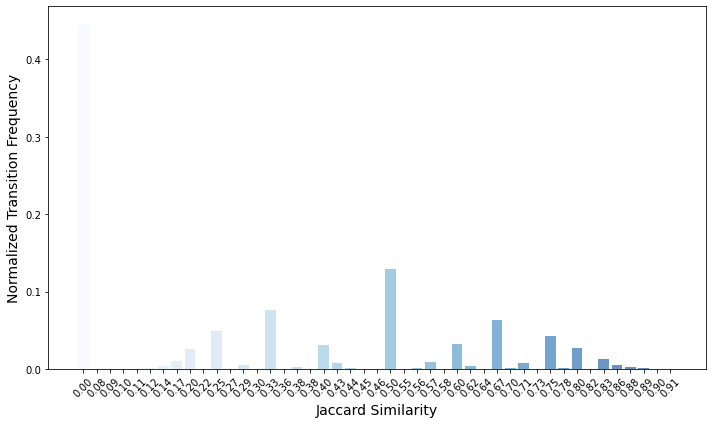

In [15]:
jaccard_scores_more_less_plot_1 = []

for keys, values in dictionary_transitions_sorted.items():
    similarity = len(set(keys[0]) & set(keys[1])) / len(set(keys[0]) | set(keys[1]))
    jaccard_scores_more_less_plot_1.append([values, similarity])

# Normalize and bin
total = sum([x[0] for x in jaccard_scores_more_less_plot_1])
normalized_data = [[x[0] / total, x[1]] for x in jaccard_scores_more_less_plot_1]

from collections import defaultdict
aggregated = defaultdict(float)
for value, key in normalized_data:
    aggregated[key] += value

aggregated_dict = dict(sorted(aggregated.items()))
x = list(aggregated_dict.keys())
y = list(aggregated_dict.values())

import seaborn as sns
import matplotlib.pyplot as plt

colors = sns.color_palette("Blues", len(x))
plt.figure(figsize=(10, 6))
plt.bar(range(len(x)), y, color=colors, alpha=0.6, label="Normalized Frequency")
plt.xticks(ticks=range(len(x)), labels=[f"{val:.2f}" for val in x], rotation=45)
plt.xlabel("Jaccard Similarity", fontsize=14)
plt.ylabel("Normalized Transition Frequency", fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/3s/xgfhtpqj3d31_g5rxc7tttp0g7nxt3/T/ipykernel_47094/1148665683.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[trans for sim, trans in y_normalized_jac],


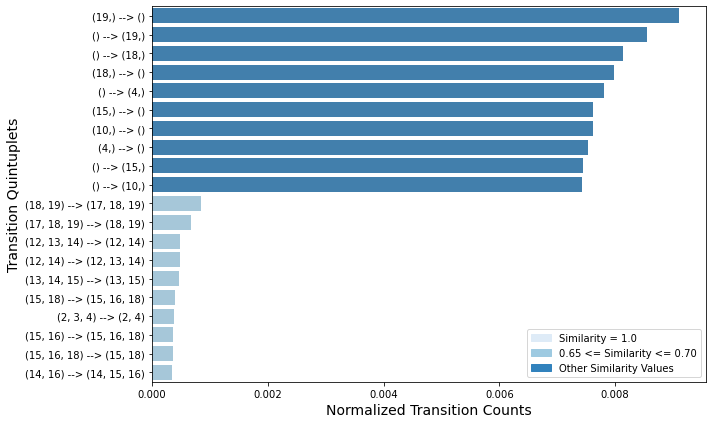

In [16]:
import matplotlib.patches as mpatches

jaccard_scores_more_less = {}
count_more_1 = 0
count_less_70 = 0
count_less_60 = 0

for keys, values in dictionary_transitions_sorted.items():
    j_similarity = len(set(keys[0]) & set(keys[1])) / len(set(keys[0]) | set(keys[1]))
    if count_more_1 < 10 and j_similarity == 1.0:
        jaccard_scores_more_less[keys] = (j_similarity, values)
        count_more_1 += 1
    elif count_less_70 < 10 and 0.65 <= j_similarity <= 0.70:
        jaccard_scores_more_less[keys] = (j_similarity, values)
        count_less_70 += 1
    elif count_less_60 < 10 and j_similarity <= 0.60:
        jaccard_scores_more_less[keys] = (j_similarity, values)
        count_less_60 += 1

# Normalize transition values
y_sum = sum(dictionary_transitions_sorted.values())
y_normalized_jac = [(sim, trans / y_sum) for sim, trans in jaccard_scores_more_less.values()]
x_jac = list(jaccard_scores_more_less.keys())

# Assign colors by similarity
colors = []
for sim, _ in y_normalized_jac:
    if sim == 1.0:
        colors.append("#deebf7")
    elif 0.65 <= sim <= 0.70:
        colors.append("#9ecae1")
    else:
        colors.append("#3182bd")

# Plot horizontal bar with actual quintuplet labels
clean_data = [ (tuple(int(x) for x in pair[0]), tuple(int(x) for x in pair[1])) for pair in x_jac ]

plt.figure(figsize=(10, 6))
sns.barplot(x=[trans for sim, trans in y_normalized_jac],
            y=[f"{k[0]} --> {k[1]}" for k in clean_data],
            palette=colors)

blue_patch_1 = mpatches.Patch(color="#deebf7", label="Similarity = 1.0")
blue_patch_2 = mpatches.Patch(color="#9ecae1", label="0.65 <= Similarity <= 0.70")
blue_patch_3 = mpatches.Patch(color="#3182bd", label="Other Similarity Values")

plt.legend(handles=[blue_patch_1, blue_patch_2, blue_patch_3], loc="lower right")
plt.xlabel('Normalized Transition Counts', fontsize=14)
plt.ylabel('Transition Quintuplets', fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/3s/xgfhtpqj3d31_g5rxc7tttp0g7nxt3/T/ipykernel_47094/1192525141.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=[trans for sim, trans in y_normalized_jac], x=transition_labels, palette=colors)


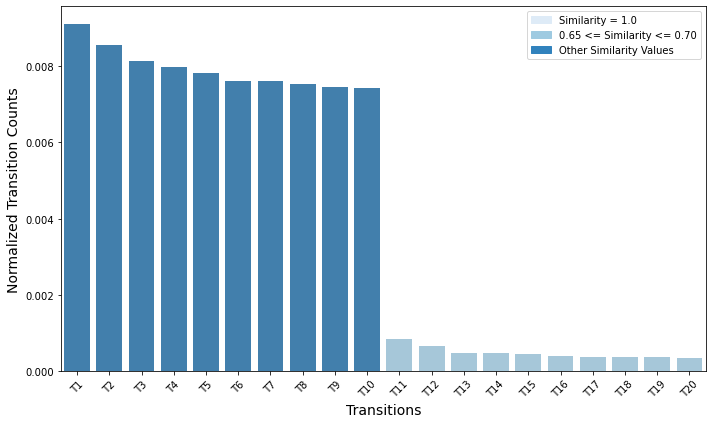

In [17]:
transition_labels = [f"T{i+1}" for i in range(len(x_jac))]

# Map to T-labels (optional if you need reverse lookup)
transition_map = {
    f"T{i+1}": (x_jac[i][0], x_jac[i][1])
    for i in range(len(x_jac))
}

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(y=[trans for sim, trans in y_normalized_jac], x=transition_labels, palette=colors)

blue_patch_1 = mpatches.Patch(color="#deebf7", label="Similarity = 1.0")
blue_patch_2 = mpatches.Patch(color="#9ecae1", label="0.65 <= Similarity <= 0.70")
blue_patch_3 = mpatches.Patch(color="#3182bd", label="Other Similarity Values")

plt.legend(handles=[blue_patch_1, blue_patch_2, blue_patch_3])
plt.ylabel('Normalized Transition Counts', fontsize=14)
plt.xlabel('Transitions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
# Assumes: dictionary_transitions_sorted is already computed
#          residues = u.select_atoms("protein").residues (from MDAnalysis)

# Get top N transitions
top_N = 20
transition_list = list(dictionary_transitions_sorted.items())[:top_N]

print(f"Top {top_N} Quintuplet Transitions and Their Residue Identities:\n")
for i, ((q1, q2), count) in enumerate(transition_list, 1):
    residues_1 = [residues[int(idx)].resname + str(residues[int(idx)].resid) for idx in q1]
    residues_2 = [residues[int(idx)].resname + str(residues[int(idx)].resid) for idx in q2]
    jaccard = len(set(q1) & set(q2)) / len(set(q1) | set(q2))
    
    print(f"Transition {i}:")
    print(f"  From: {residues_1}")
    print(f"  To:   {residues_2}")
    print(f"  Jaccard Similarity: {jaccard:.2f}")
    print(f"  Frequency: {count}")
    print("-" * 60)


Top 20 Quintuplet Transitions and Their Residue Identities:

Transition 1:
  From: ['ALA140']
  To:   []
  Jaccard Similarity: 0.00
  Frequency: 690
------------------------------------------------------------
Transition 2:
  From: []
  To:   ['ALA140']
  Jaccard Similarity: 0.00
  Frequency: 648
------------------------------------------------------------
Transition 3:
  From: []
  To:   ['GLU139']
  Jaccard Similarity: 0.00
  Frequency: 616
------------------------------------------------------------
Transition 4:
  From: ['GLU139']
  To:   []
  Jaccard Similarity: 0.00
  Frequency: 604
------------------------------------------------------------
Transition 5:
  From: []
  To:   ['TYR125']
  Jaccard Similarity: 0.00
  Frequency: 592
------------------------------------------------------------
Transition 6:
  From: ['TYR136']
  To:   []
  Jaccard Similarity: 0.00
  Frequency: 577
------------------------------------------------------------
Transition 7:
  From: ['GLU131']
  To:   []
 